In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [16]:

dataset = pd.read_csv("marketing_campaign.csv", sep=",")

dataset["Income"] = dataset["Income"].fillna(dataset["Income"].median())

dataset = dataset[dataset["Income"] < 200000]

dataset["Total_Spending"] = (
    dataset["MntWines"] +
    dataset["MntFruits"] +
    dataset["MntMeatProducts"] +
    dataset["MntFishProducts"] +
    dataset["MntSweetProducts"] +
    dataset["MntGoldProds"]
)

features = [
    "Income",
    "Recency",
    "Total_Spending",
    "NumWebPurchases",
    "NumStorePurchases"
]

X = dataset[features].values

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

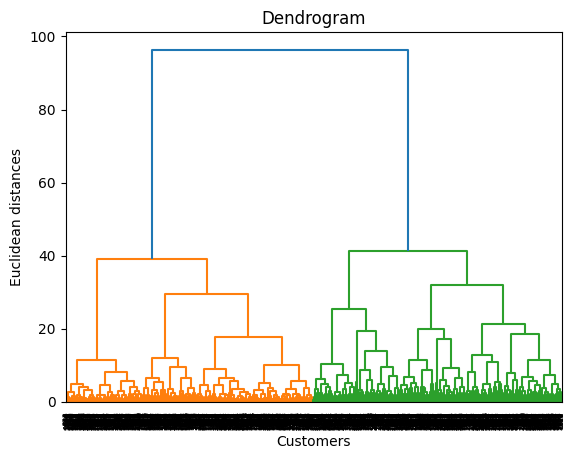

In [18]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method = 'ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X_scaled)

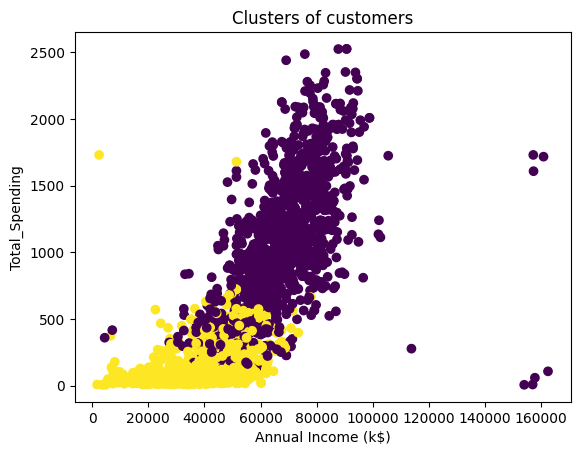

In [20]:
plt.scatter(dataset["Income"], dataset["Total_Spending"], c=y_hc)
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Total_Spending')
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

print(silhouette_score(X_scaled, y_hc))

0.36638245415456877


In [22]:
for k in range(2, 8):
    hc = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = hc.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(k, score)

2 0.36638245415456877
3 0.28814419535647506
4 0.21478356874401971
5 0.20930567409612444
6 0.20217327746951055
7 0.20792815929860645
